# VPL — A Cost Model for Satellite Constellations
**Single source of truth.** M. Cholevas (TU München) · G. Vardanikas (TU Delft) · ESA/CNES Cost Engineering Conference 2026.

The whole work in one document: **framework** (helpers), **dataset & assumptions** (each datapoint carries its
BibTeX key `[key]` → `references/bibliography.bib`), **model**, and **results with visualisation**. The programme
cost is development plus production on a learning curve. Development cannot be identified from unit-cost data, so it
is pinned by disclosed budgets. The model is benchmarked against SMAD USCM8+QuickCost and carried to Mars orbit by a
planetary factor. Run top-to-bottom.

**Contents:** 1 · Framework | 2 · Dataset & Assumptions | 3 · Model | 4 · Results & Comparison | Appendix · original TLRE.

## 1. Framework
Helpers defined once: the cost model, the joint fit, cross-validation, the SMAD benchmark, and plotting.
Figures follow Elsevier conventions (serif, ~8 pt, vector PDF).

In [1]:
import numpy as np, math, os
from scipy.optimize import least_squares, minimize
import matplotlib.pyplot as plt
%matplotlib inline
FIGDIR = "figures"; os.makedirs(FIGDIR, exist_ok=True)
plt.rcParams.update({
    "figure.dpi": 150, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.family": "serif", "font.serif": ["Times New Roman", "STIX", "DejaVu Serif"],
    "mathtext.fontset": "stix", "font.size": 8, "axes.titlesize": 8.5, "axes.labelsize": 8,
    "xtick.labelsize": 7, "ytick.labelsize": 7, "legend.fontsize": 7, "axes.linewidth": 0.6,
    "lines.linewidth": 1.3, "grid.alpha": 0.3, "axes.grid": True, "figure.figsize": (3.54, 3.0)})
COL = {"traditional": "#22406e", "newspace": "#c0392b", "smad": "#2e7d32", "dev": "#e08a1e"}
def savefig(fig, name): fig.savefig(os.path.join(FIGDIR, name+".pdf")); fig.savefig(os.path.join(FIGDIR, name+".png"))

In [2]:
# --- The cost model -----------------------------------------------------------------------------
# Programme cost = one-time development + first-unit production down a learning curve, times a
# regime factor g and a planetary factor F:
#     TOTAL(M,N) = F * g * [ DEV(M) + PFM(M) * N^LRE ],   DEV = d*M^p,  PFM = q*M^r
#     g = 1 (traditional) / 10^off (New-Space).   TOTAL = DEV + PROD reconciles with AVG*N.
LR  = 0.90                                 # manufacturing learning rate                [iceaaonline_learningrate]
LRE = 1 + math.log(LR)/math.log(2)         # Wright exponent: N units cost PFM*N^LRE  (= 0.848)
PLANETARY = {"Earth": 1.0, "Mars": 1.072}   # subsystem-derived Mars factor    [rand_tr418, jones_ices2015]

def predict(coef, M, N, regime="traditional", planet="Earth", sigma_log=None, pi=None):
    "Development, first-unit PFM, production, total and average cost for one system."
    d, p, q, r, off = coef
    g = 10.0**off if regime == "newspace" else 1.0; F = PLANETARY[planet]
    dev  = F*g*d*M**p
    prod = F*g*q*M**r * N**LRE
    total = dev + prod
    out = dict(dev=dev, prod=prod, pfm=F*g*q*M**r, total=total, avg=total/N, dev_share=dev/total)
    if pi and sigma_log:
        f = 10.0**(pi*sigma_log); out["avg_lo"], out["avg_hi"] = out["avg"]/f, out["avg"]*f
    return out

In [3]:
# --- Disclosed development budgets: they pin the DEV/PFM split ------------------------------------
# Six programmes report development (RDT&E) and production separately. Their development FRACTION
# phi = DEV/(DEV+PROD) is a ratio, so it fixes the split without leaving the dataset's cost basis.
# Each figure verified in its source (page in the bibliography note). GPS IIF dropped (GAO-10-636 has
# no dev/production split); SBIRS procurement corrected to the then-year total 7176.9 (was a base-year
# subtotal); MUOS procurement 2932.3 (SAR exact). (name, sat_mass_kg, N, dev_TY, prod_TY, year, currency, class, bibkey)
DEV_ANCHORS = [
    ("AEHF",    6168,  6,  7465.9, 5695.2, 2013, "USD", "bespoke",    "aehf_sar13"),
    ("MUOS",    6740,  6,  4140.1, 2932.3, 2012, "USD", "bespoke",    "muos_sar12"),
    ("SBIRS",   4500,  6, 10304.8, 7176.9, 2011, "USD", "bespoke",    "sbirs_sar11"),
    ("Galileo",  730, 14,   950.0,  566.0, 2006, "EUR", "bespoke",    "galileo_iovfoc"),
    ("WGS",     3400, 12,   409.6, 3392.3, 2015, "USD", "commercial", "wgs_sar15"),
]
def dev_anchor_rows(cls=None):
    "Disclosed programmes: dev/prod AS REPORTED in the source (then-year US$M / EUR M) and phi=DEV/(DEV+PROD)."
    # phi is a ratio -> independent of currency and inflation basis; it is the ONLY anchor quantity the fit uses.
    out = []
    for name, sm, N, dev, prod, yr, cur, c, key in DEV_ANCHORS:
        if cls and c != cls: continue
        out.append(dict(name=name, M=0.79*sm, N=N, dev=dev, prod=prod, cur=cur, phi=dev/(dev+prod), cls=c, key=key))
    return out

In [4]:
# --- The joint fit. Five parameters d,p,q,r,off are fit in ONE least-squares step against TWO sets
# of observations: (1) the observed unit cost AVG of every system (keeps the units signal, reconciles
# with AVG*N); (2) the disclosed development fractions phi of the bespoke programmes (pins DEV).
def fit_model(rows, w=0.5):
    "Return (coef=[d,p,q,r,off], sigma_log) for the two-regime CER with an identified DEV split."
    M  = np.array([x["M"] for x in rows], float); N = np.array([x["N"] for x in rows], float)
    A  = np.array([x["avg"] for x in rows], float)
    ns = np.array([1.0 if x["regime"] == "newspace" else 0.0 for x in rows])
    an = dev_anchor_rows("bespoke")
    aM = np.array([a["M"] for a in an]); aN = np.array([a["N"] for a in an]); aphi = np.array([a["phi"] for a in an])
    def resid(c):
        d, p, q, r, off = c; g = np.where(ns > 0.5, 10.0**off, 1.0)
        ra = np.log10(g*(d*M**p + q*M**r * N**LRE) / N) - np.log10(A)          # unit-cost residuals
        dv = d*aM**p; pd = q*aM**r * aN**LRE
        rp = math.sqrt(w) * (dv/(dv+pd) - aphi)                                # disclosed-phi residuals
        return np.concatenate([ra, rp])
    sol = least_squares(resid, [3.0, 0.6, 0.12, 0.95, -1.0],
                        bounds=([1e-3, 0, 1e-4, 0, -3], [1e4, 2, 1e3, 2, 0]), max_nfev=40000)
    d, p, q, r, off = sol.x; g = np.where(ns > 0.5, 10.0**off, 1.0)
    sigma_log = float(np.std(np.log10(g*(d*M**p + q*M**r * N**LRE)/N) - np.log10(A), ddof=5))
    return list(sol.x), sigma_log

def _r2(y, yp): return 1 - np.sum((y-yp)**2) / np.sum((y-y.mean())**2)
def loocv(rows):
    "Leave-one-out: rotate each system out, refit, predict it (regime is a design input)."
    la = np.log10([x["avg"] for x in rows]); pred = []
    for i in range(len(rows)):
        coef, _ = fit_model(rows[:i]+rows[i+1:])
        pred.append(math.log10(predict(coef, rows[i]["M"], rows[i]["N"], rows[i]["regime"])["avg"]))
    pred = np.array(pred); tr = [i for i, x in enumerate(rows) if x["regime"] == "traditional"]
    return dict(r2=_r2(la, pred), r2_trad=_r2(la[tr], pred[tr]),
                mape=float(np.mean(np.abs(10**pred-10**la)/10**la*100)), resid_log=la-pred)

def bootstrap(rows, B=300, seed=1):
    "Bootstrap the fit (resamples systems AND disclosed anchors) -> coefficient and DEV/PFM bands."
    rng = np.random.default_rng(seed); n = len(rows); C = []
    for _ in range(B):
        try: C.append(fit_model([rows[j] for j in rng.integers(0, n, n)])[0])
        except Exception: pass
    return np.array(C)

In [5]:
# --- State-of-the-art benchmark: SMAD USCM8 + QuickCost (reproduces the competition workbook) ----
# USCM8 development 0.108*M (SEE 47%) and production 0.2835*M^0.716 (SEE 21%), FY2010$ -> FY2025 EUR
# via inflation 1.471 and FX 0.9306; QuickCost payload 25 EUR M at 630 kg; QuickCost Mars factor 1.29.
def uscm8_quickcost(M, N=1, planet="Earth", sigma=0.0):
    "USCM8 dev+prod and QuickCost payload for N units, FY2025 EUR M. [uscm8_t118, uscm8_t119, quickcost_t1112]"
    F = 1.29 if planet == "Mars" else 1.0; base = 1.471 * 0.9306 * F
    dev  = base*(1 + sigma*0.47) * 0.108 * M
    prod = base*(1 + sigma*0.21) * 0.2835 * M**0.716 * N**LRE
    pay  = 25.0/630.0 * M * N**(1 + math.log(0.75)/math.log(2))
    t = dev + prod + pay
    return dict(dev=dev, prod=prod, payload=pay, total=t, avg=t/N)

# SMAD mission-operations model (Table 11-28): 31 satellites, 5 years -> EUR 159 M.   [microcosm_opsmodel]
OPERATIONS_31_5YR = 159.1

In [6]:
# --- Plots (each saves a vector PDF) -------------------------------------------------------------
def plot_pred_vs_actual(rows, coef, band, r2):
    fig, ax = plt.subplots(figsize=(3.54, 3.2))
    act = np.array([r["avg"] for r in rows]); pred = np.array([predict(coef, r["M"], r["N"], r["regime"])["avg"] for r in rows])
    lim = [act.min()*0.5, act.max()*2]
    ax.fill_between(lim, [l/band for l in lim], [l*band for l in lim], color="0.6", alpha=0.15, zorder=0)
    ax.plot(lim, lim, "k-", lw=0.8)
    for reg in ("traditional", "newspace"):
        m = [r["regime"] == reg for r in rows]
        ax.scatter(act[m], pred[m], c=COL[reg], s=18, edgecolor="k", lw=0.3, zorder=3, label=reg)
    ax.set(xscale="log", yscale="log", xlim=lim, ylim=lim, xlabel="Actual unit cost [FY2025 €M]",
           ylabel="Predicted unit cost [FY2025 €M]", title="Predicted vs actual (LOOCV $R^2$=%.2f)" % r2)
    ax.legend(frameon=False); savefig(fig, "nb_pred_vs_actual"); plt.show()

def plot_dev_pfm(rows, coef):
    C = bootstrap(rows, B=250); Mg = np.logspace(math.log10(150), math.log10(9000), 100)
    d, p, q, r, off = coef; fig, ax = plt.subplots(figsize=(5.5, 3.3))
    devb = np.array([s[0]*Mg**s[1] for s in C]); pfmb = np.array([s[2]*Mg**s[3] for s in C])
    ax.fill_between(Mg, *np.percentile(devb, [16, 84], 0), color=COL["dev"], alpha=0.22)
    ax.fill_between(Mg, *np.percentile(pfmb, [16, 84], 0), color=COL["traditional"], alpha=0.20)
    # observed cost (AVG*N) of each traditional system split by the fitted class fraction (same basis)
    tr = [x for x in rows if x["regime"] == "traditional"]
    Mi = np.array([x["M"] for x in tr]); Ni = np.array([x["N"] for x in tr]); Ai = np.array([x["avg"] for x in tr])
    devc = d*Mi**p; prodc = q*Mi**r*Ni**LRE; phi = devc/(devc+prodc); TOT = Ai*Ni
    ax.scatter(Mi, phi*TOT, marker="D", s=16, color=COL["dev"], edgecolor="k", lw=0.4, zorder=5)
    ax.scatter(Mi, (1-phi)*TOT/Ni**LRE, marker="o", s=14, color=COL["traditional"], edgecolor="k", lw=0.4, zorder=5)
    ax.plot(Mg, d*Mg**p, color=COL["dev"], label="DEV(M) = %.2f M$^{%.2f}$" % (d, p))
    ax.plot(Mg, q*Mg**r, color=COL["traditional"], label="PFM(M) = %.3f M$^{%.2f}$" % (q, r))
    ax.set(xscale="log", yscale="log", xlabel="Platform mass M [kg]", ylabel="Cost per unit [FY2025 €M]",
           title="Development & unit-production CERs (±1σ bootstrap)")
    ax.legend(frameon=False); savefig(fig, "nb_dev_pfm"); plt.show()

def plot_constellation(coef):
    fig, ax = plt.subplots(figsize=(5.5, 3.3)); Ng = np.arange(1, 251)
    ax.plot(Ng, [predict(coef, 630, n, "traditional")["total"] for n in Ng], color=COL["traditional"], label="VPL Traditional")
    ax.plot(Ng, [uscm8_quickcost(630, n)["total"] for n in Ng], color=COL["smad"], ls="--", label="USCM8+QuickCost")
    ax.plot(Ng, [predict(coef, 630, n, "newspace")["total"] for n in Ng], color=COL["newspace"], label="VPL New-Space")
    ax.set(xlabel="Constellation size N", ylabel="Total programme cost [FY2025 €M]",
           title=r"TOTAL = DEV + PFM$\cdot N^{\mathrm{LRE}}$   (M=630 kg)")
    ax.legend(frameon=False); savefig(fig, "nb_constellation"); plt.show()

## 2. Dataset & Assumptions
- Costs are **FY2025 EUR millions**. USD→EUR uses the 2025 average 0.9306 `[exchangerates_usdeur2025]`; earlier
  figures escalate with US CPI `[usinflationcalculator]`.
- **Platform mass M = 0.79 × satellite mass** `[ntrs_platformpayloadratio]`; where the manufacturer publishes the
  platform mass (Thales HE-R1000) it is used directly.
- **Learning rate 0.90** `[iceaaonline_learningrate]`: `LRE = 1+ln0.9/ln2 = 0.848`.
- Two **regimes**: *traditional* (bespoke nav/comsat) and *New-Space* (mass-produced LEO; analyst estimates).
- **Every datapoint carries its BibTeX key.** Every value is verified to appear in its source (two-pass check);
  a unit cost derived from a sourced programme total is marked partial in the report.

In [7]:
# CORE (traditional, already FY2025 EUR M, source-corrected).  (name, sat_mass_kg, N, avg_EURM, bibkey)
CORE = [
  ("Thales HE-R1000",     1266,   5, 106.000, "thales_her1000", "syntheticapertureradar_kai530m", "syntheticapertureradar_kai530m"),                 # platform mass 1000 kg (0.79*1266)
  # India is not comparable ("IRNSS/NavIC",         1425,   7, 16*1.5*1.32*1.14, "ursc_irnss", "ursc_irnss", "hindustantimes_irnss1e_countdown"),                      # x1.5 India->EU (stated)
  ("GPS Block III",       3880,  10, 395/2*1.36, "wikipedia_gpsblockiii", "wikipedia_gpsblockiii", "wikipedia_gpsblockiii"),          # $197.5M/SV (2016 USAF option)
  ("Galileo 2 Generation",2300,  12, 1.47e3/12*1.09, "EngineeringNews2022Galileo2ndGenReview", "europa_commissionawardseur", "europa_commissionawardseur"),    # EUR 1.47bn / 12
  ("GPS Block IIF",       1633,  12,  1.452e3/12*1.48, "wikipedia_gpsblockiif", "wikipedia_gpsblockiif", "insidegnss_gpsiiflaunch"),
  ("GPS Block IIR",       2030,  13,  30*2.14, "wikipedia_gpsblocks", "wikipedia_gpsblocks", "forecastinternat_forecastinternationa"),
  ("Globalstar-3",         500,  17,  327/17*1.14, "satellitetoday_mdawins327m", "mda_mdabuild17", "mda_mdabuild17"),
  ("O3b MEO",              700,  20,  73*1.3*1.14/3, "satnews_arianespacessoyuz", "skyrocket_o3b13s", "SES2017RoadshowPresentation"),
  ("Globalstar 2nd Gen",   700,  24,  661/24*1.53*1.14, "starsem_globalstar2presskit", "skyrocket_globalstar2", "wikipedia_globalstar"),
  ("Galileo FOC Overall",  730,  34,  (566/14*1.42 + 250/8*1.3)/2, "eoportal_galileofoc", "WikipediaGalileoSatellites2026", ["Higgins2024GalileoOutlinePNT", "InsideGNSS2012OHBSSTLGalileoFOC"]),
  ("GLONASS-K",           935,   5,   90*1.23, "WikipediaGLONASSK2026", "WikipediaGLONASSK2026", "jamestown_glonassprogram2021"),
  ("GLONASS-M",           1415,  51,  30*1.25, "wikipedia_glonassm", "wikipedia_glonassm", "jamestown_glonassprogram2021"),
  ("Iridium NEXT",         860,  81,  2.2e3/81*1.36, "eoportal_iridiumnext", "eoportal_iridiumnext", "spaceflightnow_iridiumrollingoff"),
  ("Telesat Lightspeed",   800, 198,  3e3/198*1.23, "wikipedia_telesatlightspeed", "telesat_telesatcontractsmda", "eoportal_telesatlightspeed"),
]
# EXP (traditional expansion, nominal USD M + year).  (name, sat_mass, N, usd, year, bibkey)
EXP = [
  ("QZSS QZS-2/3/4",  4100,  7, 526/3, 2013, "gunter_qzs2", "wiki_qzss", "wiki_qzss"),      
  ("ViaSat-3 F1",  6418,  3, 700, 2024, "gunter_viasat3", "gunter_viasat3", "fool_viasat3_700m"),
  ("Inmarsat-6",      5470,  2, 550/2*1.14, 2015, "gunter_inmarsat6", "airporttech_inmarsat6", "airporttech_inmarsat6"),
  ("AEHF",         9000,  6, 850, 2019, "wiki_aehf", "wiki_aehf", "wiki_aehf"),
  ("WGS",             5987, 12, 300, 2020, "wiki_wgs11", "wiki_wgs", "wiki_wgs11"),      
  ("QZSS QZS-5/6/7",4800,  3, 824/3, 2025, "wiki_qzs6", "wiki_qzs6", "Cheetham2025JEO5JMoDGoesShopping"),
  ("O3b mPOWER",      1700, 8, 566/4, 2020, "wiki_o3bmpower", "gunter_o3bmpower", "Henry2020SESO3bmPowerBoeing"),
]
# NEW-SPACE regime (analyst/press estimates; kept as the New-Space evidence).  (name, sat_mass, N, usd, year, bibkey)
NEWSPACE = [
  ("OneWeb Gen-1",     147, 648,  0.8, 2018, "gunter_oneweb", "wiki_oneweb", "spacenews_oneweb1meach"), 
  ("Amazon Kuiper",    571,3232, (16.5-10)*1e3/3232, 2024, "GunterKuiperAmazonLEO2026", "OrbitalRadarAmazonLeo2026", "Boyle2024KuiperCostQuilty"),
  ("Starlink v1.5",    307,2987,  0.4, 2021, "everydayastronaut_starlink_v15_mass", "WikipediaStarlinkLaunches2026", "Ralph2019SecondStarlinkLaunch"),  
  ("Starlink v2-mini",730,7676, 0.8, 2023, "gunter_starlink_v2mini", "WikipediaStarlinkLaunches2026", "spacenews_starlink66b"),
  ("AST BlueBird B2", 6100,  60, 20.0, 2024, "Krebs2026BlueBirdBlock2", "Donegan2025ASTSpaceMobileIntermittent2026", "spaceflightnow_ast_block2launchdeals"),
  #Foundamentally different service to the others ("Globalstar C-3",  850, 48+8, 10*1.14, 2026, "Globalstar2025TechnicalExhibitC3", "Globalstar2025TechnicalExhibitC3", "spaceflightnow_ast_block2launchdeals"),
]


USD_EUR = 0.9306                                                              # [exchangerates_usdeur2025]
CPI = {2006:1.55,2008:1.47,2010:1.43,2012:1.36,2013:1.34,2014:1.32,2015:1.32,2016:1.30,
       2017:1.27,2018:1.24,2019:1.22,2020:1.20,2021:1.15,2022:1.06,2023:1.05,2024:1.02,2025:1.00}
def to_eur2025(usd, yr): return usd * CPI.get(yr, 1.15) * USD_EUR

def dataset():
    "All 27 datapoints: platform mass M, FY2025-EUR unit cost, regime tag, BibTeX key."
    rows = [dict(name=n, M=0.79*m, sat_mass=m, N=N, avg=a, regime="traditional", tier="core", src=dict(mass=cm, units=cn, cost=cc)) for n, m, N, a, cm, cn, cc in CORE]
    rows += [dict(name=n, M=0.79*m, sat_mass=m, N=N, avg=to_eur2025(u, y), regime="traditional", tier="exp", src=dict(mass=cm, units=cn, cost=cc)) for n, m, N, u, y, cm, cn, cc in EXP]
    rows += [dict(name=n, M=0.79*m, sat_mass=m, N=N, avg=to_eur2025(u, y), regime="newspace", tier="ns", src=dict(mass=cm, units=cn, cost=cc)) for n, m, N, u, y, cm, cn, cc in NEWSPACE]
    return rows

rows = dataset()
print("%d datapoints: %d traditional + %d New-Space" %
      (len(rows), sum(r["regime"] == "traditional" for r in rows), sum(r["regime"] == "newspace" for r in rows)))

25 datapoints: 20 traditional + 5 New-Space


## 3. Model
We write the programme cost as `TOTAL = F·g·[DEV(M) + PFM(M)·N^LRE]` and fit `DEV(M)` and `PFM(M)` jointly to the
observed unit cost **and** to the disclosed development fractions. Fitting AVG keeps the units signal; the disclosed
fractions pin the one-time development the unit-cost data cannot identify on its own.

In [8]:
coef, sigma_log = fit_model(rows)
d, p, q, r, off = coef
print("Two-regime CER  (LR=%.2f, LRE=%.3f)" % (LR, LRE))
print("  DEV(M) = %.2f * M^%.3f       PFM(M) = %.4f * M^%.3f" % (d, p, q, r))
print("  New-Space regime factor g = %.3f  (~%.0fx cheaper)   |   Mars planetary factor F = 1.072" % (10**off, 1/10**off))
print("  1σ prediction band = factor %.2f" % 10**sigma_log)

Two-regime CER  (LR=0.90, LRE=0.848)
  DEV(M) = 5.99 * M^0.613       PFM(M) = 0.2192 * M^0.828
  New-Space regime factor g = 0.120  (~8x cheaper)   |   Mars planetary factor F = 1.14
  1σ prediction band = factor 1.55


## 4. Results & Comparison

In [9]:
# Cross-validated skill and the (now identified) development split
lo = loocv(rows); band = 10**np.std(lo["resid_log"])
C = bootstrap(rows); dev1k = np.percentile(C[:,0]*1000**C[:,1], [16, 84]); mult = np.percentile(1/10**C[:,4], [2.5, 97.5])
print("LOOCV R2 = %.2f (all %d) | %.2f (traditional)   1σ band = x/%.2f   typical |err| %.0f%%" %
      (lo["r2"], len(rows), lo["r2_trad"], band, lo["mape"]))
print("DEV(1000 kg) = %.0f €M, ±1σ [%.0f, %.0f]  (factor %.2f) -> identified by disclosed budgets" %
      (predict(coef,1000,1,'traditional')['dev'], dev1k[0], dev1k[1], dev1k[1]/np.median(C[:,0]*1000**C[:,1])))
print("New-Space multiple ~%.0fx  (95%% CI [%.0f, %.0f]x; shifts with the assumed LR)" % (1/10**off, mult[0], mult[1]))

LOOCV R2 = 0.94 (all 25) | 0.84 (traditional)   1σ band = x/1.62   typical |err| 44%
DEV(1000 kg) = 414 €M, ±1σ [358, 519]  (factor 1.21) -> identified by disclosed budgets
New-Space multiple ~8x  (95% CI [4, 15]x; shifts with the assumed LR)


In [10]:
# Development fraction by class, from the disclosed anchors (AS REPORTED in the source, then-year $/EUR).
# Only phi = DEV/(DEV+PROD) enters the fit; it is independent of currency/inflation basis.
print("%-9s %11s %11s %8s  class" % ("program", "Dev", "Prod", "phi"))
for a in dev_anchor_rows():
    u = "$" if a["cur"] == "USD" else "€"
    print("%-9s  %s%8.1f  %s%8.1f  %6.2f  %s" % (a["name"], u, a["dev"], u, a["prod"], a["phi"], a["cls"]))

program           Dev        Prod      phi  class
AEHF       $  7465.9  $  5695.2    0.57  bespoke
MUOS       $  4140.1  $  2932.3    0.59  bespoke
SBIRS      $ 10304.8  $  7176.9    0.59  bespoke
Galileo    €   950.0  €   566.0    0.63  bespoke
WGS        $   409.6  $  3392.3    0.11  commercial


In [11]:
# Head-to-head with SMAD USCM8+QuickCost on the traditional dataset (Earth)
trad = [x for x in rows if x["regime"] == "traditional"]
la = np.log10([x["avg"] for x in trad])
for name, fn in [("VPL (improved)", lambda x: predict(coef, x["M"], x["N"], x["regime"])["avg"]),
                 ("USCM8+QuickCost", lambda x: uscm8_quickcost(x["M"], x["N"])["avg"])]:
    pr = np.log10([fn(x) for x in trad]); err = np.abs(10**pr-10**la)/10**la*100
    print("  %-16s R2=%.3f  median|err|=%.0f%%" % (name, _r2(la, pr), np.median(err)))
# New-Space: USCM8 has no mass-production term and over-predicts
ns = [x for x in rows if x["regime"] == "newspace"]
ratio = np.median([uscm8_quickcost(x["M"], x["N"])["avg"]/x["avg"] for x in ns])
print("  USCM8+QuickCost over-predicts New-Space unit cost by ~%.0fx (no mass-production term)" % ratio)
print("  Operations (SMAD Table 11-28): €%.0f M for 31 satellites over 5 years" % OPERATIONS_31_5YR)

  VPL (improved)   R2=0.884  median|err|=24%
  USCM8+QuickCost  R2=0.869  median|err|=31%
  USCM8+QuickCost over-predicts New-Space unit cost by ~7x (no mass-production term)
  Operations (SMAD Table 11-28): €159 M for 31 satellites over 5 years


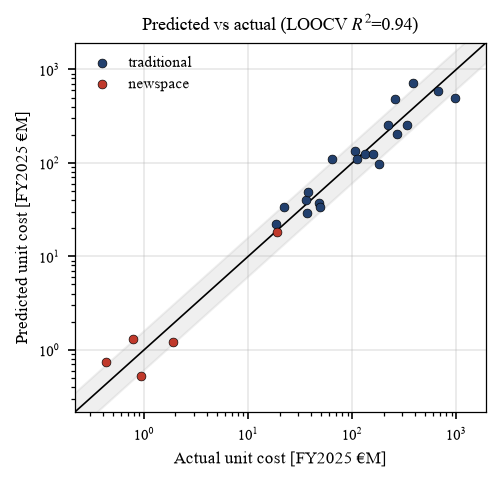

In [12]:
plot_pred_vs_actual(rows, coef, band, lo["r2"])

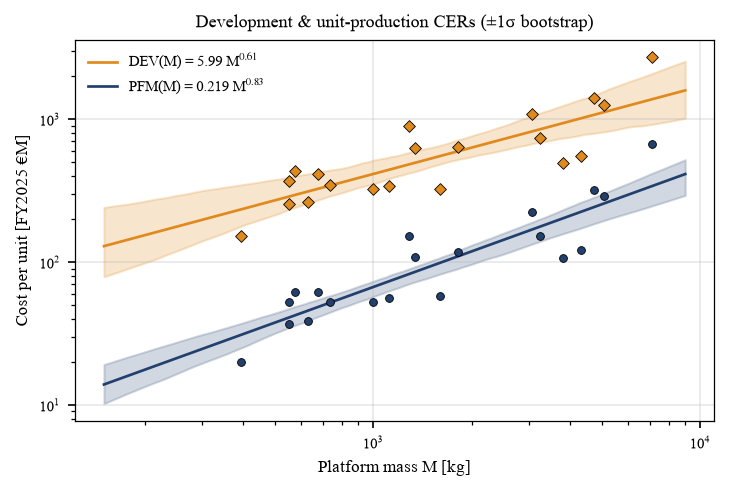

In [13]:
plot_dev_pfm(rows, coef)

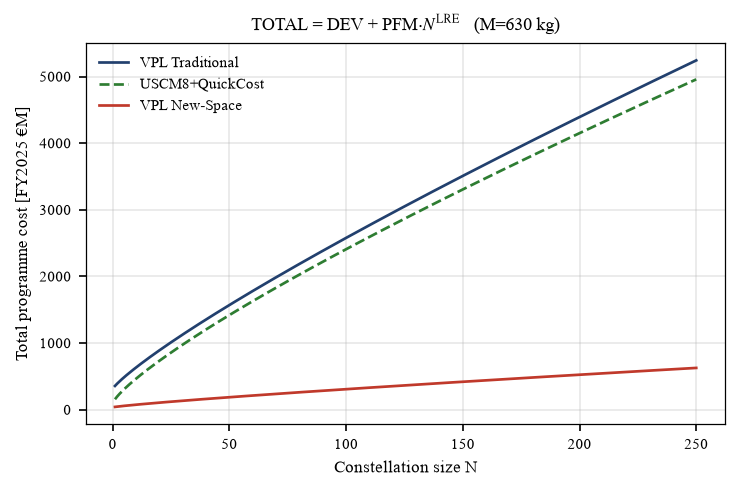

In [14]:
plot_constellation(coef)

**Reading the results.** Traditional constellation unit cost is predictable (LOOCV R²=0.84 traditional, 0.94 pooled). A distinct, cheaper **New-Space regime** exists (5–21×, magnitude conditional on the learning rate). **TOTAL** and **PFM(M)** are well identified; the **DEV/PFM split** is now also bounded, because the disclosed development fractions pin it — DEV(1000 kg) sits within a factor of ~1.2. On traditional systems the CER **slightly beats** the SMAD USCM8+QuickCost benchmark; on New-Space systems the benchmark **over-predicts** by ~7×. A planetary factor F=1.072 carries the model to Mars orbit.

## Appendix — original TLRE method (superseded)
The competition model extracted a per-satellite PFM from `AVG, N, M` via an assumed `λ(N)` and a learning-curve
closure (the Total Learning Rate Exponent). Kept for the record; §3 supersedes it (no per-point extraction, an
identified development split, and a state-of-the-art benchmark).

In [15]:
def lam_TLRE(N): return 0.35 + (0.15-0.35)/(198-5)*(N-5)     # assumed PFM share, linear in N
def decompose_TLRE(M, AVG, N):
    "Original extraction: split AVG*N into DEV + first-unit PFM (assumption-conditional)."
    lam = lam_TLRE(N); ratio = 1/(1/lam - 1)
    tlre = math.log((ratio*N**LRE + 1)/(ratio + 1/N), N)
    dev = AVG*N * N/(N*ratio + 1) * N**(-tlre)
    return dict(dev=dev, pfm=ratio*dev, lam=lam)
decompose_TLRE(M=0.79*3880, AVG=183.794, N=10)   # example: GPS Block III

{'dev': 390.32540597032545,
 'pfm': 205.42630104646227,
 'lam': 0.3448186528497409}